# Churn Prediction (Logistic Regression)
This notebook loads the churn dataset, preprocesses and scales features, trains a logistic regression model, and evaluates it on a held-out test set.

### 1) Imports & setup
- Load required libraries (pandas, scikit-learn, seaborn).
- Import project config (`DATA_PATH`) and the `preprocess` function used later.

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

import _setup
from src.config import DATA_PATH
from src.preprocess import preprocess

print('loaded all dependencies successfully...')

loaded all dependencies successfully...


### 2) Load dataset
- Read the churn dataset from `DATA_PATH` into a DataFrame `df`.

In [18]:
# Loading the dataset

df = pd.read_csv(DATA_PATH)

print('loaded dataset successfully...')

loaded dataset successfully...


### 3) Preprocess + split data
- Run `preprocess(df)` to clean/encode features.
- Create `X` (features) and `y` (target `Churn`).
- Split into train/test with stratification to keep churn class balance.

In [19]:
# Spliiting train and test sets

data = preprocess(df)

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print('train and test data splitted successfully...')

train and test data splitted successfully...


### 4) Scale numeric features
- Standardize selected numeric columns.
- Fit the scaler on the training set and transform both training and test data.

In [20]:
# Scaling of train and test sets

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('scaled numeric columns of both train and test sets')

scaled numeric columns of both train and test sets


### 5) Train logistic regression
- Create a `LogisticRegression` model with `class_weight='balanced'` to handle class imbalance.
- Fit the model on `X_train` and `y_train`.

In [29]:
# Fitting the model

model = LogisticRegression(class_weight='balanced')

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### 6) Predict and compute metrics
- Predict labels for `X_test` using the trained model.
- Compute accuracy, precision, recall, and F1 score against `y_test`.

In [30]:
y_pred = model.predict(X_test)

print('Test Results :-')
print(f'Accuracy = {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision = {precision_score(y_test, y_pred):.2f}')
print(f'Recall = {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score = {f1_score(y_test, y_pred):.2f}')


Test Results :-
Accuracy = 0.74
Precision = 0.50
Recall = 0.78
F1 Score = 0.61


### 7) Confusion matrix
- Build a confusion matrix from `y_test` and `y_pred`.
- Plot it as a heatmap to visualize errors.

<Axes: >

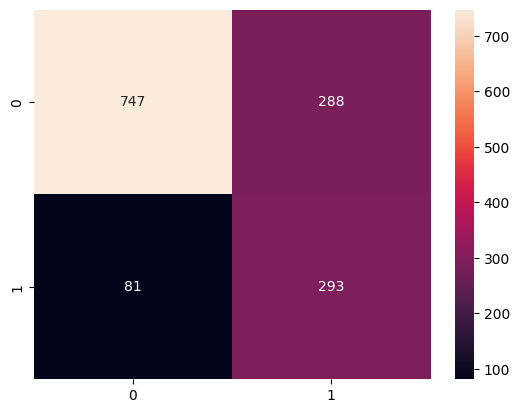

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

### Model Performance Summary

The logistic regression model was trained using balanced class weights to address class imbalance. The performance on the test set is as follows:

- **Accuracy:** 0.74  
- **Precision:** 0.50  
- **Recall:** 0.78  
- **F1 Score:** 0.61  

### Observations

- The model achieves a **high recall (0.78)**, meaning it successfully identifies most customers who are likely to churn.  
- Precision is moderate (0.50), indicating that some non-churning customers are incorrectly classified as churners.  
- This trade-off is acceptable in churn prediction, as failing to identify a churner (false negative) is more costly than incorrectly flagging a non-churner (false positive).  
- The model provides a strong baseline and demonstrates the effectiveness of logistic regression for this problem.